In [1]:
from modulos.data_load import load
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
10 // 3

3

In [3]:
df = load('AAVEBTC')
df

,unix,date,symbol,open,high,low,close,Volume AAVE,Volume BTC,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage
41405,1602288000000,2020-10-10 00:00:00,AAVE/BTC,0.003800,0.009801,0.003800,0.004801,0.001804,0.338493,0.0,0.0,0,0.005331
41404,1602352800000,2020-10-10 18:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000380,0.100026,0.0,0.0,0,0.000000
41403,1602356400000,2020-10-10 19:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
41402,1602360000000,2020-10-10 20:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
41401,1602363600000,2020-10-10 21:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
3,1751403600000,2025-07-01 21:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
2,1751407200000,2025-07-01 22:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
1,1751410800000,2025-07-01 23:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398


In [4]:
predictors = [ 'unix', 'Volume AAVE', 'Volume BTC', 'tradeCount', 'weightedAverage' ]
outcome = 'close'

X = df[predictors]
y = df[outcome]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73337544, -0.42295094, -0.4478413 , -0.48562777,  2.69946448],
       [-1.73186963, -0.42758056, -0.45041118, -0.48562777, -1.13293601],
       [-1.73178597, -0.42881603, -0.45148912, -0.48562777, -1.13293601],
       ...,
       [ 1.73183488, -0.42881603, -0.45148912, -0.48562777,  0.59101947],
       [ 1.73191853, -0.42881603, -0.45148912, -0.48562777,  0.59101947],
       [ 1.73200219, -0.42881603, -0.45148912, -0.48562777,  0.59101947]],
      shape=(41406, 5))

In [5]:
regg = MLPRegressor(hidden_layer_sizes=(50,100,50), activation='relu', max_iter=800, random_state=1)
regg.fit(X_scaled, y)
regg.predict(X_scaled)

array([0.00307202, 0.00311094, 0.00315735, ..., 0.00128096, 0.0012798 ,
       0.00127864], shape=(41406,))

In [ ]:
len(set(regg.predict(X_scaled)))

41406

In [ ]:
dff = df
dff['PREDICTED'] = regg.predict(X_scaled)
dff

,unix,date,symbol,open,high,low,close,Volume AAVE,Volume BTC,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage,PREDICTED
41405,1602288000000,2020-10-10 00:00:00,AAVE/BTC,0.003800,0.009801,0.003800,0.004801,0.001804,0.338493,0.0,0.0,0,0.005331,0.003072
41404,1602352800000,2020-10-10 18:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000380,0.100026,0.0,0.0,0,0.000000,0.003111
41403,1602356400000,2020-10-10 19:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003157
41402,1602360000000,2020-10-10 20:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003158
41401,1602363600000,2020-10-10 21:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001283
3,1751403600000,2025-07-01 21:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001282
2,1751407200000,2025-07-01 22:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001281
1,1751410800000,2025-07-01 23:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001280


In [9]:
dff = dff[[ 'symbol', 'date', 'close', 'PREDICTED' ]].rename(columns={ 'close': 'FECHAMENTO REAL' })
dff['ERRO'] = dff[['FECHAMENTO REAL', 'PREDICTED']].apply(lambda row: abs(row['FECHAMENTO REAL'] - row['PREDICTED']), axis=1)
dff

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
41405,AAVE/BTC,2020-10-10 00:00:00,0.004801,0.003072,0.001729
41404,AAVE/BTC,2020-10-10 18:00:00,0.003800,0.003111,0.000689
41403,AAVE/BTC,2020-10-10 19:00:00,0.003800,0.003157,0.000643
41402,AAVE/BTC,2020-10-10 20:00:00,0.003800,0.003158,0.000642
41401,AAVE/BTC,2020-10-10 21:00:00,0.003800,0.003158,0.000642
...,...,...,...,...,...
4,AAVE/BTC,2025-07-01 20:00:00,0.002398,0.001283,0.001115
3,AAVE/BTC,2025-07-01 21:00:00,0.002398,0.001282,0.001116
2,AAVE/BTC,2025-07-01 22:00:00,0.002398,0.001281,0.001117
1,AAVE/BTC,2025-07-01 23:00:00,0.002398,0.001280,0.001118


In [10]:
dff[dff['ERRO'] == dff['ERRO'].max()]

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
34939,AAVE/BTC,2021-07-07 03:00:00,0.009486,0.075255,0.065768


In [12]:
0.065768 * 600_000.00


39460.799999999996

In [11]:
dff[dff['ERRO'] == dff['ERRO'].min()]

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
5220,AAVE/BTC,2024-11-26 12:00:00,0.001835,0.001835,1.872238e-09


In [14]:
1.872238e-09 * 600_000.00

0.0011233427999999999

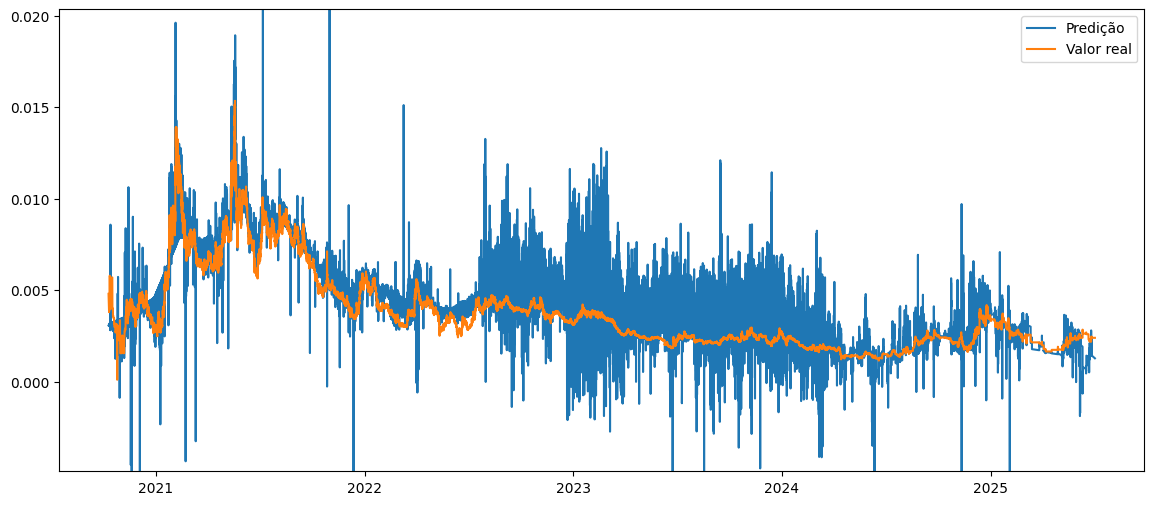

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(dff['date'], dff['PREDICTED'], label='Predição')
plt.plot(dff['date'], dff['FECHAMENTO REAL'], label='Valor real')
plt.ylim(dff['FECHAMENTO REAL'].min()-0.005, dff['FECHAMENTO REAL'].max()+0.005)
plt.legend()

In [9]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from modulos.data_load import load, coins
from sklearn.model_selection import TimeSeriesSplit


def preparar_dados(n_splits=5):
    resultados = {}

    for coin in coins:
        df = load(coin)
        print(f'Processando moeda: {coin}')
        
        df = df.sort_values('date').reset_index(drop=True)

        # Features derivadas
        df['faixa_preco'] = df['high'] - df['low']
        df['retorno_pct_7d'] = df['close'].pct_change(7)
        df['momentum_7d'] = df['close'] - df['close'].shift(7)
        df['media_movel_7d'] = df['close'].rolling(window=7).mean()
        df['std_7d'] = df['close'].rolling(window=7).std()
        df['volume_2_7d'] = df['Volume 2'].rolling(window=7).mean()

        # Evita divisão por zero usando np.where
        df['taker_ratio'] = np.where(df['Volume 2'] != 0, df['buyTakerAmount'] / df['Volume 2'], np.nan)
        df['buy_pressure'] = np.where(df['tradeCount'] != 0, df['buyTakerQuantity'] / df['tradeCount'], np.nan)
        df['volume_volatilidade_ratio'] = np.where(df['faixa_preco'] != 0, df['Volume 2'] / df['faixa_preco'], np.nan)

        df['date'] = pd.to_datetime(df['date'])
        df['dia_da_semana'] = df['date'].dt.dayofweek

        df.dropna(inplace=True)
        df.reset_index(drop=True, inplace=True)

        features = [
            'media_movel_7d', 'std_7d', 'momentum_7d', 'retorno_pct_7d',
            'volume_2_7d', 'taker_ratio', 'buy_pressure', 'volume_volatilidade_ratio',
            'dia_da_semana'
        ]

        tscv = TimeSeriesSplit(n_splits=n_splits)
        folds = []

        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(df)):
            df_train = df.iloc[train_idx].copy()
            df_val = df.iloc[val_idx].copy()

            scaler = StandardScaler()
            scaler.fit(df_train[features])

            df_train.loc[:, features] = scaler.transform(df_train[features])
            df_val.loc[:, features] = scaler.transform(df_val[features])

            folds.append({
                'train': df_train,
                'val': df_val,
                'scaler': scaler
            })

        resultados[coin] = folds

    return resultados

folds_por_moeda = preparar_dados()

for coin, folds in folds_por_moeda.items():
    print(f"\nMoeda: {coin}")
    for i, fold in enumerate(folds, start=1):
        print(f"  Fold {i}: Train shape = {fold['train'].shape},  Val shape = {fold['val'].shape}")



Processando moeda: AAVEBTC
Processando moeda: AAVEUSDT
Processando moeda: ACMUSDD
Processando moeda: ADAUSDT
Processando moeda: BNBUSDT
Processando moeda: BNTUSDT
Processando moeda: CVTBTC
Processando moeda: DOGEBTC
Processando moeda: ETCETH
Processando moeda: USDPUSDT

Moeda: AAVEBTC
  Fold 1: Train shape = (2482, 23),  Val shape = (2482, 23)
  Fold 2: Train shape = (4964, 23),  Val shape = (2482, 23)
  Fold 3: Train shape = (7446, 23),  Val shape = (2482, 23)
  Fold 4: Train shape = (9928, 23),  Val shape = (2482, 23)
  Fold 5: Train shape = (12410, 23),  Val shape = (2482, 23)

Moeda: AAVEUSDT
  Fold 1: Train shape = (4208, 23),  Val shape = (4204, 23)
  Fold 2: Train shape = (8412, 23),  Val shape = (4204, 23)
  Fold 3: Train shape = (12616, 23),  Val shape = (4204, 23)
  Fold 4: Train shape = (16820, 23),  Val shape = (4204, 23)
  Fold 5: Train shape = (21024, 23),  Val shape = (4204, 23)

Moeda: ACMUSDD
  Fold 1: Train shape = (351, 23),  Val shape = (350, 23)
  Fold 2: Train sha